In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from statsmodels.tsa.arima.model import ARIMA

In [7]:
rel = pd.read_csv("Quote-Equity-RELIANCE-EQ-24-03-2026-24-04-2026.csv")
tcs = pd.read_csv("Quote-Equity-TCS-EQ-24-03-2026-24-04-2026.csv")

print(rel.head())

          DATE SERIES      OPEN      HIGH       LOW PREV. CLOSE       LTP  \
0  24-Apr-2026     EQ  1,340.00  1,345.90  1,325.00    1,343.40  1,331.00   
1  23-Apr-2026     EQ  1,346.00  1,355.50  1,340.70    1,362.10  1,344.40   
2  22-Apr-2026     EQ  1,350.30  1,366.00  1,349.10    1,353.30  1,362.00   
3  21-Apr-2026     EQ  1,359.00  1,369.80  1,350.10    1,363.30  1,354.90   
4  20-Apr-2026     EQ  1,363.20  1,373.00  1,352.80    1,365.00  1,361.10   

      CLOSE      VWAP     52W H     52W L    VOLUME               VALUE  \
0  1,327.80  1,333.01  1,611.80  1,267.00  11744802  15,65,59,32,416.20   
1  1,343.40  1,347.84  1,611.80  1,267.00  16385079  22,08,44,84,854.70   
2  1,362.10  1,360.40  1,611.80  1,267.00   9525953  12,95,91,00,398.90   
3  1,353.30  1,356.60  1,611.80  1,267.00  27293629  37,02,64,49,570.40   
4  1,363.30  1,365.92  1,611.80  1,267.00  13614733  18,59,65,70,380.60   

   NO. OF  TRADES  
0          197088  
1          209218  
2          153909  
3     

In [8]:
rel_close = rel["CLOSE"].replace(',', '', regex=True).astype(float)
tcs_close = tcs["CLOSE"].replace(',', '', regex=True).astype(float)

data = pd.DataFrame({
    "RELIANCE": rel_close,
    "TCS": tcs_close
})

# remove bad values
data = data.dropna()
data = data.replace([np.inf, -np.inf], 0)

print(data.head())

NameError: name 'np' is not defined

In [ ]:
arima_model = ARIMA(data["RELIANCE"], order=(3,1,0))
arima_fit = arima_model.fit()

data["REL_PRED"] = arima_fit.predict(start=0, end=len(data)-1)

# clean again
data = data.dropna()

print(data.head())

   RELIANCE     TCS     REL_PRED
0    1327.8  2396.9     0.000000
1    1343.4  2521.8  1327.641100
2    1362.1  2538.5  1340.522837
3    1353.3  2610.5  1352.687499
4    1363.3  2579.6  1344.535277


In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data["RELIANCE"].values, label="Actual (RELIANCE)", linewidth=2)
plt.plot(data["REL_PRED"].values, label="ARIMA Forecast", linewidth=2, linestyle="--")
plt.title("ARIMA Forecast vs Actual - RELIANCE")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.savefig("arima_forecast_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print(data.columns)
print(data.isnull().sum())

Index(['RELIANCE', 'TCS', 'REL_PRED'], dtype='str')
RELIANCE    0
TCS         0
REL_PRED    0
dtype: int64


In [ ]:
class PortfolioEnv(gym.Env):
    def __init__(self, data):
        super().__init__()
        self.data = data.reset_index(drop=True)
        self.current_step = 0

        self.action_space = spaces.Box(low=0, high=1, shape=(2,), dtype=np.float32)
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(3,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([
            self.data.loc[self.current_step, "RELIANCE"],
            self.data.loc[self.current_step, "TCS"],
            self.data.loc[self.current_step, "REL_PRED"]
        ], dtype=np.float32)

    def step(self, action):
        # safe action
        action = np.clip(action, 1e-6, 1)
        action = action / np.sum(action)

        price_now = self.data.loc[self.current_step, ["RELIANCE", "TCS"]].values
        price_next = self.data.loc[self.current_step+1, ["RELIANCE", "TCS"]].values

        # safe return
        returns = (price_next - price_now) / (price_now + 1e-6)
        portfolio_return = np.dot(returns, action)

        # safe reward
        portfolio_return = np.clip(portfolio_return, -0.99, 10)
        reward = np.log(1 + portfolio_return + 1e-6)

        self.current_step += 1
        terminated = self.current_step >= len(self.data) - 1
        truncated = False

        return self._get_obs(), reward, terminated, truncated, {}

In [ ]:
env = PortfolioEnv(data)

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=20000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 19       |
|    ep_rew_mean     | 0.032    |
| time/              |          |
|    fps             | 826      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19           |
|    ep_rew_mean          | 0.0343       |
| time/                   |              |
|    fps                  | 696          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0033338666 |
|    clip_fraction        | 0.0146       |
|    clip_range           | 0.2          |
|    en

In [ ]:
obs, _ = env.reset()
returns = []

for _ in range(len(data)-1):
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)

    returns.append(np.exp(reward) - 1)

    if terminated or truncated:
        break

returns = np.array(returns)

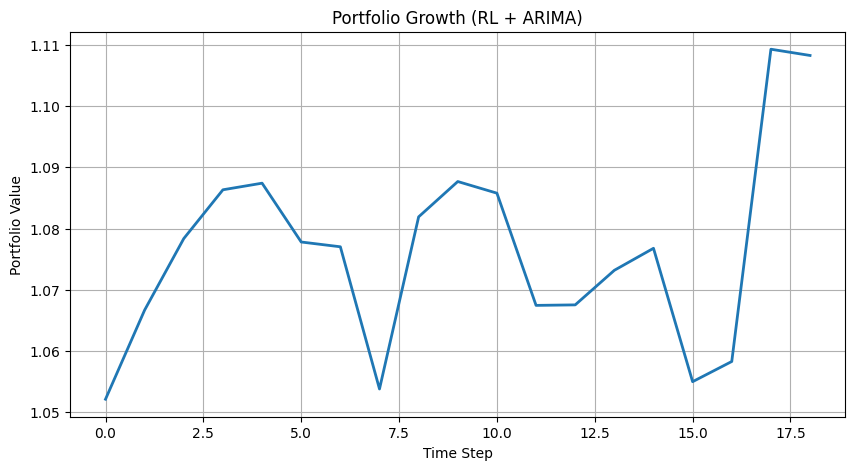

In [ ]:
portfolio_curve = np.cumprod(1 + returns)

plt.figure(figsize=(10,5))
plt.plot(portfolio_curve, linewidth=2)
plt.title("Portfolio Growth (RL + ARIMA)")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.grid()
plt.show()

In [ ]:
# Baseline (equal weight)
baseline_returns = (
    (data["RELIANCE"].pct_change() + data["TCS"].pct_change()) / 2
).dropna()

baseline_curve = np.cumprod(1 + baseline_returns)

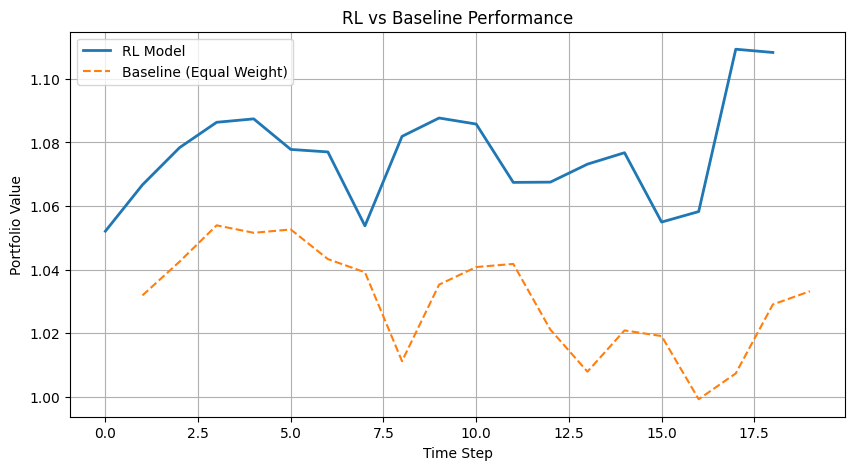

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(portfolio_curve, label="RL Model", linewidth=2)
plt.plot(baseline_curve, label="Baseline (Equal Weight)", linestyle="--")

plt.title("RL vs Baseline Performance")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Sharpe Ratio (RL)
sharpe_rl = np.mean(returns) / (np.std(returns) + 1e-6)

print("Sharpe Ratio (RL):", sharpe_rl)

Sharpe Ratio (RL): 0.2951813914983503


In [ ]:
final_value = portfolio_curve[-1]
days = len(portfolio_curve)

annual_return = (final_value ** (252 / days)) - 1

print("Annual Return (RL):", annual_return)

Annual Return (RL): 2.9102652031789833


In [ ]:
baseline_returns = (
    (data["RELIANCE"].pct_change() + data["TCS"].pct_change()) / 2
).dropna()

sharpe_base = np.mean(baseline_returns) / (np.std(baseline_returns) + 1e-6)

print("Sharpe Ratio (Baseline):", sharpe_base)

Sharpe Ratio (Baseline): 0.122563287763013


In [ ]:
baseline_curve = np.cumprod(1 + baseline_returns)

final_base = baseline_curve.iloc[-1]
days_base = len(baseline_curve)

annual_base = (final_base ** (252 / days_base)) - 1

print("Annual Return (Baseline):", annual_base)

Annual Return (Baseline): 0.5427679948185868
